GitHub :

# An Analysis of Credit Card Customer Segmentation Using Unsupervised Clustering Methods

##  Importing Required Libraries

In this section, we import all the necessary Python libraries for data analysis, visualization, preprocessing, and clustering.

In [14]:
#import packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from kneed import KneeLocator

from sklearn.preprocessing import StandardScaler, normalize
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN

from sklearn.model_selection import GridSearchCV

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

## Loading the Dataset

In this section, we load the dataset into a pandas DataFrame and perform initial inspection.

###  Steps Performed
- Load the dataset using `pandas`
- View the first few rows
- Check the shape of the dataset (rows and columns)
- Understand the structure of the data

In [15]:
data = pd.read_csv('CreditCard_dataset.csv')

# Drop customer ID column
data = data.drop(columns=['CUST_ID'])

# Replace null values correctly (no chained assignment)
data['MINIMUM_PAYMENTS'] = data['MINIMUM_PAYMENTS'].fillna(0)

data.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Missing Values Analysis

In this step, we check for missing (NaN) values in each feature of the dataset.

###  Why This Matters
- Missing data can affect clustering performance  
- Some algorithms cannot handle NaN values directly  
- Helps decide whether to clean, fill, or drop data  

We compute the total number of missing values per column.

In [16]:
#Check the NaN count per features
null_count = data.isna().sum()
null_count

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        1
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64

## Handling Missing Values

In this step, we remove rows that contain missing values from the dataset.

### Why This Approach?
- The dataset contains very few missing values  
- Dropping them has minimal impact on the overall data  
- Simplifies preprocessing for clustering algorithms  

Specifically, we remove rows with missing values in the **CREDIT LIMIT** feature.

In [17]:
#Drops the one CREDIT LIMIT Missing value row
data.dropna(inplace=True)
data.head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Feature Scaling

In this step, we standardize the dataset using **StandardScaler**.

### Why Scaling is Important
- Clustering algorithms (like KMeans, DBSCAN) are distance-based  
- Features with larger values can dominate the results  
- Scaling ensures all features contribute equally  

### What StandardScaler Does
- Transforms data to have:
  - Mean = 0  
  - Standard Deviation = 1  

This process is also known as **standardization (z-score normalization)**.

In [18]:
scaler = StandardScaler()
scale_data = scaler.fit_transform(data)
scale_data = pd.DataFrame(scale_data, columns=data.columns)
scale_data.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.732054,-0.249881,-0.424934,-0.356957,-0.349114,-0.466805,-0.806649,-0.678716,-0.707409,-0.675294,-0.476083,-0.511381,-0.960380,-0.529026,-0.297334,-0.525588,0.360541
1,0.786858,0.134049,-0.469584,-0.356957,-0.454607,2.605438,-1.221928,-0.678716,-0.917090,0.573949,0.110032,-0.591841,0.688601,0.818546,0.101998,0.234159,0.360541
2,0.447041,0.517980,-0.107716,0.108843,-0.454607,-0.466805,1.269742,2.673295,-0.917090,-0.675294,-0.476083,-0.109082,0.826016,-0.383857,-0.088524,-0.525588,0.360541
3,0.049015,-1.017743,0.231995,0.546123,-0.454607,-0.368678,-1.014290,-0.399383,-0.917090,-0.258882,-0.329554,-0.551611,0.826016,-0.598733,-0.357057,-0.525588,0.360541
4,-0.358849,0.517980,-0.462095,-0.347317,-0.454607,-0.466805,-1.014290,-0.399383,-0.917090,-0.675294,-0.476083,-0.551611,-0.905414,-0.364421,-0.252265,-0.525588,0.360541


## Dimensionality Reduction using PCA

In this step, we apply **Principal Component Analysis (PCA)** to reduce the dataset to 2 dimensions.

### Why PCA?
- Reduces the number of features while preserving important information  
- Helps remove noise and redundancy  
- Improves clustering performance  
- Enables easy visualization in 2D  

### What We Do
- Transform the scaled data into 2 principal components  
- Create a new DataFrame with `pc1` and `pc2`

In [19]:
#Fit our dataframe into 2 components
pca = PCA(n_components=2)
pca = pca.fit_transform(scale_data)
pca = pd.DataFrame(pca, columns=['pc1', 'pc2'])
pca.index = data.index
pca.head()

,pc1,pc2
0,-1.684484,-1.070217
1,-1.132568,2.510222
2,0.968926,-0.383446
3,-0.897248,-0.017765
4,-1.600519,-0.681375


## Optimal Number of Clusters (Elbow Method)

In this step, we determine the optimal number of clusters (**k**) using the **Elbow Method**.

### What is the Elbow Method?
- It evaluates clustering performance for different values of k  
- Uses **inertia (sum of squared distances)** as a metric  
- The goal is to find a point where improvement slows down  

### Key Idea
- As k increases → inertia decreases  
- At some point, the rate of decrease sharply changes  
- This point is called the **"elbow"** → optimal k  

We also use **KneeLocator** to automatically detect this point.

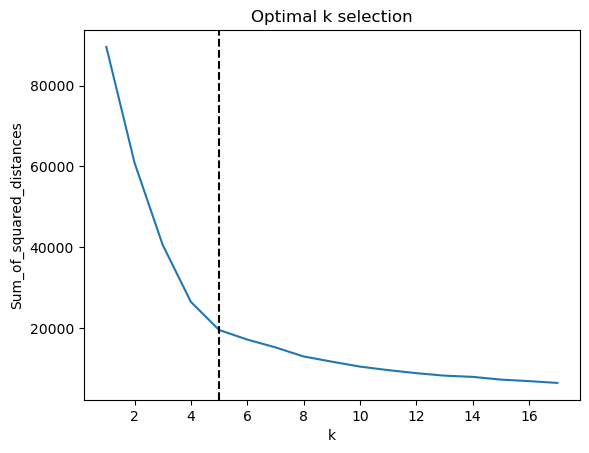

In [36]:
sum_of_squared_distances = []
#Tests k values between 1 through 17 (inclusive)
K = range(1,18)
for k in K:
    km = KMeans(n_clusters=k, n_init=10)
    km = km.fit(pca)
    #Evaluation Metric to find optimal K parameter
    sum_of_squared_distances.append(km.inertia_)

#Uses elbow method to kind optimal K
location = KneeLocator(range(1,18), sum_of_squared_distances, S=1.0, curve="convex", direction="decreasing")
optimal_k = location.elbow

plt.plot(range(1,18),sum_of_squared_distances)
plt.axvline(optimal_k, color="black", linestyle="--")
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Optimal k selection')
plt.savefig("Optimal k selection- elbow")
plt.show()

## KMeans Hyperparameter Tuning

In this step, we optimize the performance of the KMeans clustering model using **GridSearchCV**.

### Why Tune Hyperparameters?
- Default parameters may not produce the best clustering  
- Different configurations can significantly affect results  
- We aim to find the best combination automatically  

### Parameters Tuned
- **n_init:** Number of times KMeans runs with different initial centroids  
- **init:** Method for initializing centroids (`k-means++` or `random`)  
- **max_iter:** Maximum number of iterations  

### Evaluation Metric
We use the **Silhouette Score**, which measures:
- How similar a point is to its own cluster  
- Compared to other clusters  

Higher score → better clustering

In [21]:
kmeans = KMeans()

def KMeans_silhouette_score(estimator, X):
    labels = estimator.fit_predict(X)
    score = silhouette_score(X, labels)
    return score

param_grid = {
    'n_init' : [1, 3, 5, 10, 15],
    'init': ['k-means++', 'random'],  
    'max_iter': [100, 200, 300]   
}

grid_search = GridSearchCV(estimator=kmeans, param_grid=param_grid, scoring=KMeans_silhouette_score, cv=5)
grid_search.fit(pca) 

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Hyperparameters:", best_params)
print("Best Silhouette Score:", best_score)

Best Hyperparameters: {'init': 'k-means++', 'max_iter': 100, 'n_init': 3}
Best Silhouette Score: 0.39084410137859205


##  Final KMeans Clustering Model

In this step, we train the final KMeans model using:
- Optimal number of clusters (from Elbow Method)  
- Best hyperparameters (from GridSearchCV)  

### What We Do
- Fit the KMeans model on PCA-transformed data  
- Assign cluster labels to each data point  
- Append cluster labels to the dataset  

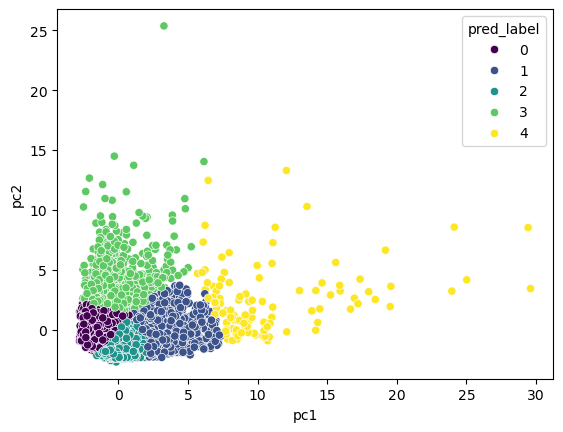

In [37]:
best_params['n_clusters'] = optimal_k
km = KMeans(**best_params)

km = km.fit(pca)
labels = km.labels_

pca['pred_label'] = labels
sns.scatterplot(pca, x='pc1', y='pc2', hue='pred_label', palette='viridis')
plt.savefig("KMeans Cluster Visualization")

## Advanced Cluster Validation using Silhouette Analysis

In this section, we perform a detailed evaluation of KMeans clustering using multiple values of k.

### Purpose
- Validate the optimal number of clusters  
- Compare clustering performance across different k values  
- Use both numerical metrics and visual diagnostics  

###  Evaluation Metrics

- **Silhouette Score** (↑ better)
- **Davies-Bouldin Index** (↓ better)
- **Calinski-Harabasz Index** (↑ better)

###  Visualization
Silhouette plots provide a visual representation of:
- Cluster cohesion (tightness)
- Cluster separation (distance between clusters)

Number of clusters: 3
Silhouette Score: 0.48
Davies-Bouldin Index: 0.80
Calinski-Harabasz Index: 4939.60
----------------------------------------


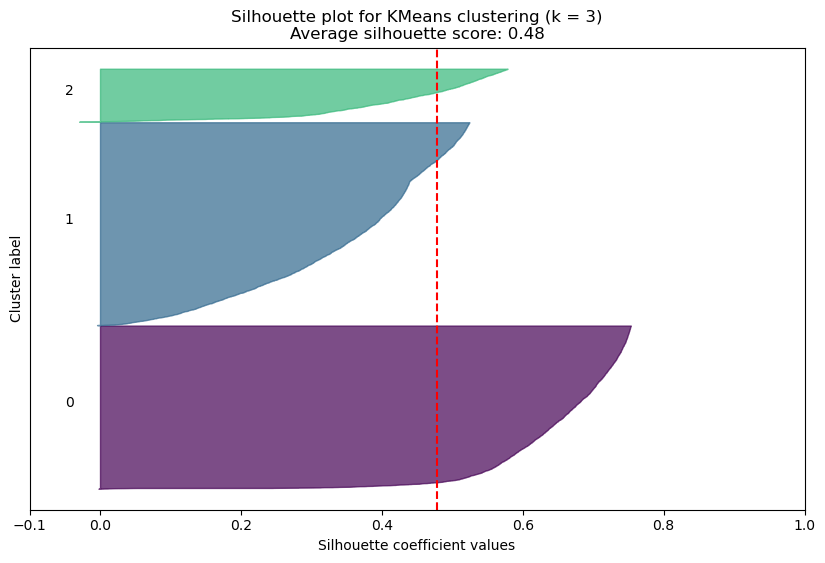

Number of clusters: 4
Silhouette Score: 0.52
Davies-Bouldin Index: 0.74
Calinski-Harabasz Index: 6557.97
----------------------------------------


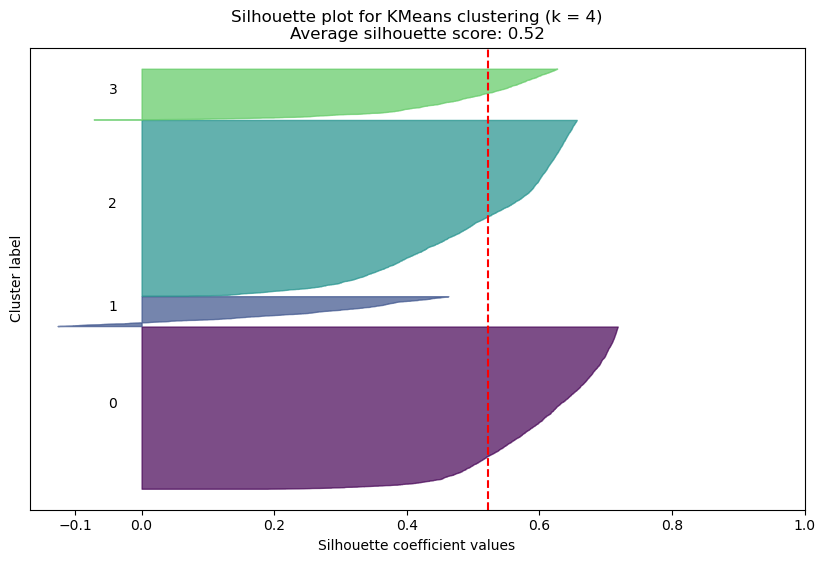

Number of clusters: 5
Silhouette Score: 0.54
Davies-Bouldin Index: 0.68
Calinski-Harabasz Index: 7385.29
----------------------------------------


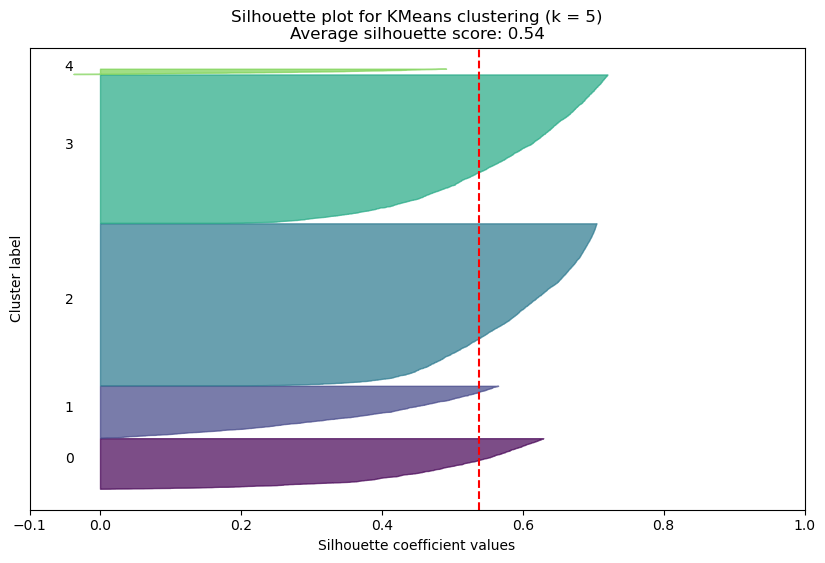

Number of clusters: 6
Silhouette Score: 0.54
Davies-Bouldin Index: 0.79
Calinski-Harabasz Index: 6991.69
----------------------------------------


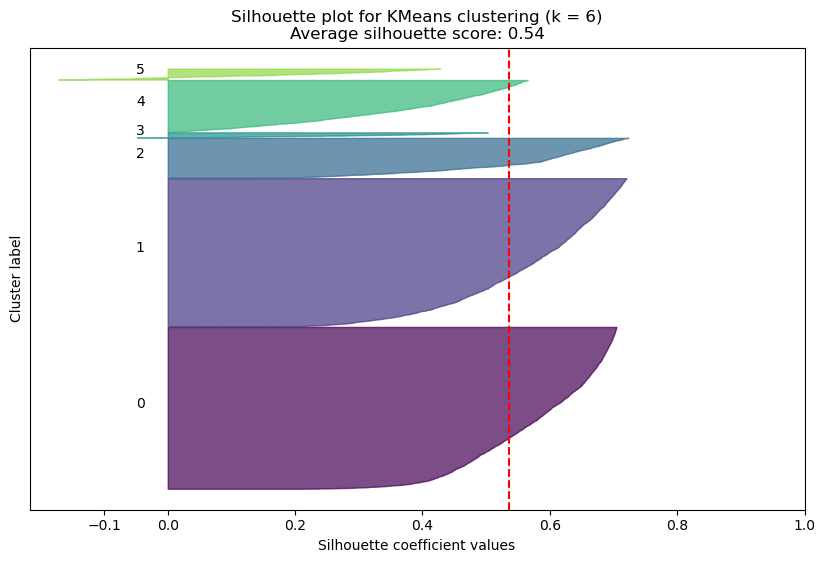

Number of clusters: 7
Silhouette Score: 0.53
Davies-Bouldin Index: 0.82
Calinski-Harabasz Index: 6804.38
----------------------------------------


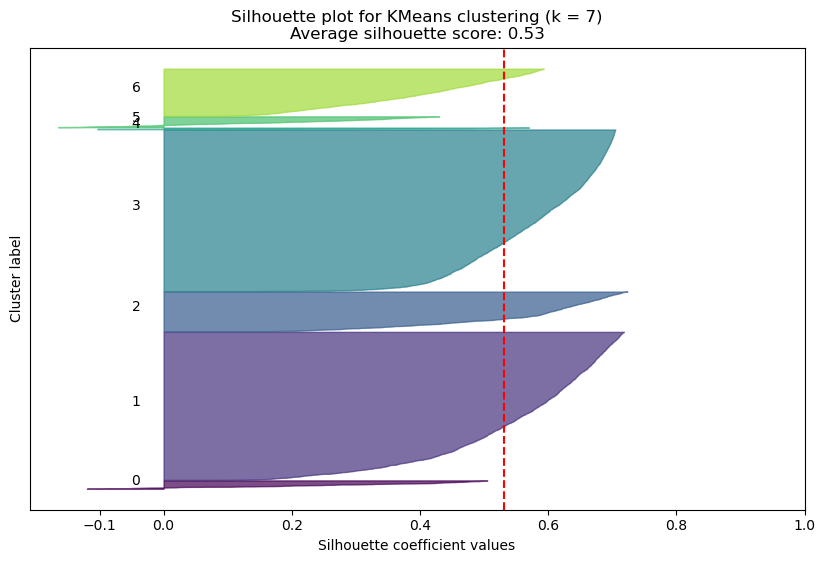

In [40]:
range_n_clusters = [3, 4, 5, 6, 7]

for n_clusters in range_n_clusters:
    km = KMeans(n_clusters, n_init=10)
    km.fit(pca)

    silhouette_values = silhouette_samples(pca, km.labels_)
    silhouette_avg = silhouette_score(pca, km.labels_)    
    db_score = davies_bouldin_score(pca, km.labels_)
    ch_score = calinski_harabasz_score(pca, km.labels_)
    
    # Print clustering evaluation metrics
    print(f"Number of clusters: {n_clusters}")
    print(f"Silhouette Score: {silhouette_avg:.2f}")
    print(f"Davies-Bouldin Index: {db_score:.2f}")
    print(f"Calinski-Harabasz Index: {ch_score:.2f}")
    print("----------------------------------------")

    plt.figure(figsize=(10, 6))
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_values[km.labels_ == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = plt.cm.viridis(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        y_lower = y_upper + 10
        plt.title(f"Silhouette plot for KMeans clustering (k = {n_clusters})\nAverage silhouette score: {silhouette_avg:.2f}")
    plt.xlabel("Silhouette coefficient values")
    plt.ylabel("Cluster label")
    plt.axvline(x=silhouette_avg, color="red", linestyle="--")
    plt.yticks([])  # Clear the yaxis labels / ticks
    plt.xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.show()
    

## Gaussian Mixture Model Selection (BIC Criterion)

In this section, we evaluate different Gaussian Mixture Model (GMM) configurations using the **Bayesian Information Criterion (BIC)**.

###  Why GMM?
- Unlike KMeans, GMM allows **soft clustering** (probabilistic assignment)  
- Can model clusters with different shapes and distributions  

### What is BIC?
- A model selection criterion  
- Balances model fit and complexity  
- Penalizes overly complex models  

### Key Idea
- **Lower BIC score → Better model**  

We compare models with different:
- Number of components  
- Covariance types  

## Final GMM Model Selection

### Key Insight
- The best model is the one with the **lowest BIC score**
 
### Covariance Types Explained
- **full** → most flexible (each cluster has its own covariance matrix)  
- **tied** → all clusters share the same covariance  
- **diag** → diagonal covariance (no feature correlation)  
- **spherical** → simplest (equal variance in all directions)  

### conclusion
This configuration will be used to build the final Gaussian Mixture Model.

## GMM Model Selection using BIC

We evaluate different Gaussian Mixture Model configurations using the **Bayesian Information Criterion (BIC)**.

### Key Concept
- BIC balances:
  - Model fit  
  - Model complexity  
### Parameters Compared
- Number of components (clusters)  
- Covariance type (cluster shape flexibility)  

In [29]:
df = pd.DataFrame(grid_search.cv_results_)[
    ["param_eps", "param_min_samples", "mean_test_score"]
]

df = df.rename(columns={
    "param_eps": "eps",
    "param_min_samples": "min_samples",
    "mean_test_score": "silhouette_score"
})

df.sort_values(by="silhouette_score", ascending=False).head()

,eps,min_samples,silhouette_score
0,0.1,2,-1.0
1,0.1,6,-1.0
2,0.1,10,-1.0
3,0.1,14,-1.0
4,0.1,18,-1.0


# Gaussian Mixture Model (GMM)

In this section, we apply the **Gaussian Mixture Model (GMM)** using the optimal number of components.

### Steps Performed
- Reduce dimensionality using PCA (2 components)  
- Fit GMM on transformed data  
- Predict cluster labels  
- Visualize clusters in 2D space  

### Why GMM?
- Allows **soft clustering** (probabilistic assignment)  
- Can capture more complex cluster shapes than KMeans  

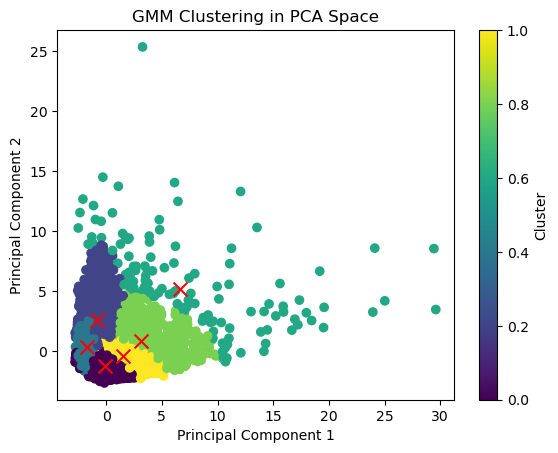

Davies-Bouldin Index: 1.1900999424054504
Calinski-Harabasz Index: 3777.5593480934663


<Figure size 640x480 with 0 Axes>

In [41]:
n_components = 2
pca_gmm = PCA(n_components)
pca_gmm = pca_gmm.fit_transform(scale_data.values)

n_components_gmm = 6 
gmm = GaussianMixture(n_components_gmm)
gmm.fit(pca_gmm)

labels = gmm.predict(pca_gmm)

db_score = davies_bouldin_score(pca_gmm, labels)
ch_score = calinski_harabasz_score(pca_gmm, labels)

plt.scatter(pca_gmm[:, 0], pca_gmm[:, 1], c=labels)
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c='red', marker='x', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('GMM Clustering in PCA Space')
plt.colorbar(label='Cluster')
plt.savefig("GMM Clustering in PCA Space")
plt.show()


print("Davies-Bouldin Index:", db_score)
print("Calinski-Harabasz Index:", ch_score)

## DBSCAN Hyperparameter Tuning

In this section, we optimize the **DBSCAN clustering algorithm** using GridSearchCV.

###  Why DBSCAN?
- Detects clusters of arbitrary shapes  
- Identifies noise (outliers) automatically  
- Does not require specifying number of clusters  

###  Parameters Tuned

- **eps (ε):**
  - Maximum distance between two points to be considered neighbors  

- **min_samples:**
  - Minimum number of points required to form a cluster  

###  Evaluation Metric
We use **Silhouette Score** to evaluate clustering quality.

Special Handling:
- If only one cluster is found OR noise dominates → score = -1  

In [31]:
DBSCAN_pca = pd.DataFrame(pca, columns=['pc1', 'pc2'])

dbscan = DBSCAN()
#Creates the silhouette score error function to find the most optimum
def DBSCAN_silhouette_score(estimator, X):
    labels = estimator.fit_predict(X)
    unique_labels = np.unique(labels)
    if len(unique_labels) <= 1 or -1 in unique_labels:
        return -1
    else:
        return silhouette_score(X, labels)
    
param_grid = {
    'eps': [0.1, 0.5, 1.0, 1.5, 2.0],  
    'min_samples': [2, 6, 10, 14, 18, 22]      
}

grid_search = GridSearchCV(estimator=dbscan, param_grid=param_grid, scoring=DBSCAN_silhouette_score, cv=5)

grid_search.fit(DBSCAN_pca)

print("Best Parameters:", grid_search.best_params_)
print("Best Silhouette Score:", grid_search.best_score_)

Best Parameters: {'eps': 0.1, 'min_samples': 2}
Best Silhouette Score: -1.0


# Final DBSCAN Clustering

In this section, we apply the DBSCAN algorithm using the optimal parameters.

### 🔹 What We Do
- Fit DBSCAN on PCA-transformed data  
- Assign cluster labels  
- Visualize clusters  

### 🔹 Key Feature of DBSCAN
- Automatically detects **outliers (noise)**  
- Labels noise points as **-1**  

<Axes: xlabel='pc1', ylabel='pc2'>

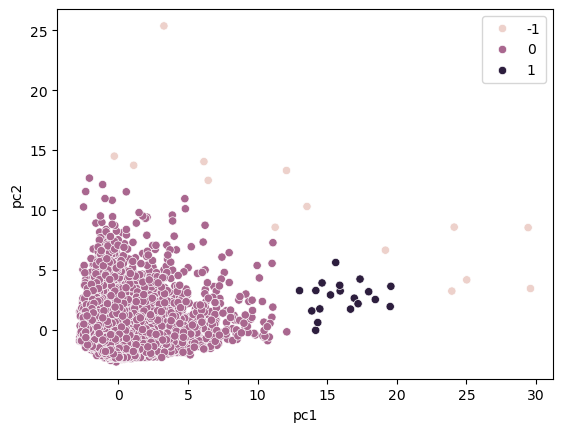

In [32]:
dbscan = DBSCAN(eps=2, min_samples=4)
dbscan_labels = dbscan.fit_predict(DBSCAN_pca)
dbscan_silhouette_score = silhouette_score(DBSCAN_pca, dbscan_labels)

sns.scatterplot(DBSCAN_pca, x='pc1' ,y='pc2', hue=dbscan_labels)

## KMeans Cluster Profiling

In this section, we analyze the characteristics of each cluster produced by the KMeans model.

### Objective
- Understand how data points differ across clusters  
- Identify meaningful patterns  
- Translate clusters into actionable insights  

### Approach
We compute the **average value of each feature per cluster** to understand cluster behavior.

In [33]:
km = KMeans(n_clusters=optimal_k, n_init=10)
#Use our scale data to find the clusters
km = km.fit(scale_data)
labels = km.labels_
data['KMeans_pred_label'] = labels
KMeans_stats = data.groupby(by='KMeans_pred_label').mean()
#Creates a dataframe with the summarized stats of each feature and cluster
KMeans_stats.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
KMeans_pred_label,,,,,,,,,,,,,,,,,
0,1893.400240,0.979339,2916.566171,1986.694776,930.304921,353.408743,0.923747,0.734122,0.585110,0.058192,1.154624,43.521676,6972.541382,2776.468069,819.342437,0.266129,11.888006
1,4541.393882,0.976638,15777.311395,10689.027791,5088.283605,1060.190695,0.928101,0.763090,0.781501,0.085271,2.988372,130.197674,12493.023256,15581.496801,3383.304083,0.394721,11.965116
2,4616.977320,0.967882,493.136111,302.052352,191.172014,4623.363303,0.280563,0.130454,0.182218,0.490732,14.649306,7.368056,7547.920612,3589.972494,2019.417524,0.035889,11.380208
3,645.955449,0.902331,797.744495,166.429623,631.809188,178.096535,0.856537,0.083195,0.794342,0.038047,0.709611,16.647059,3199.132690,935.045366,662.860663,0.271560,11.454847
4,1051.088979,0.797032,278.931482,225.848988,53.284815,619.569625,0.163421,0.096915,0.065744,0.118664,2.205980,2.951188,3342.325581,1005.913641,539.915352,0.070684,11.456683


## Feature Distribution Across Clusters

In this section, we visualize how each feature varies across KMeans clusters.

### Objective
- Compare feature values across clusters  
- Identify patterns and distinguishing characteristics  
- Support cluster interpretation visually  

### Visualization Method
- Bar plots for each feature  
- X-axis → Cluster labels  
- Y-axis → Average feature values  

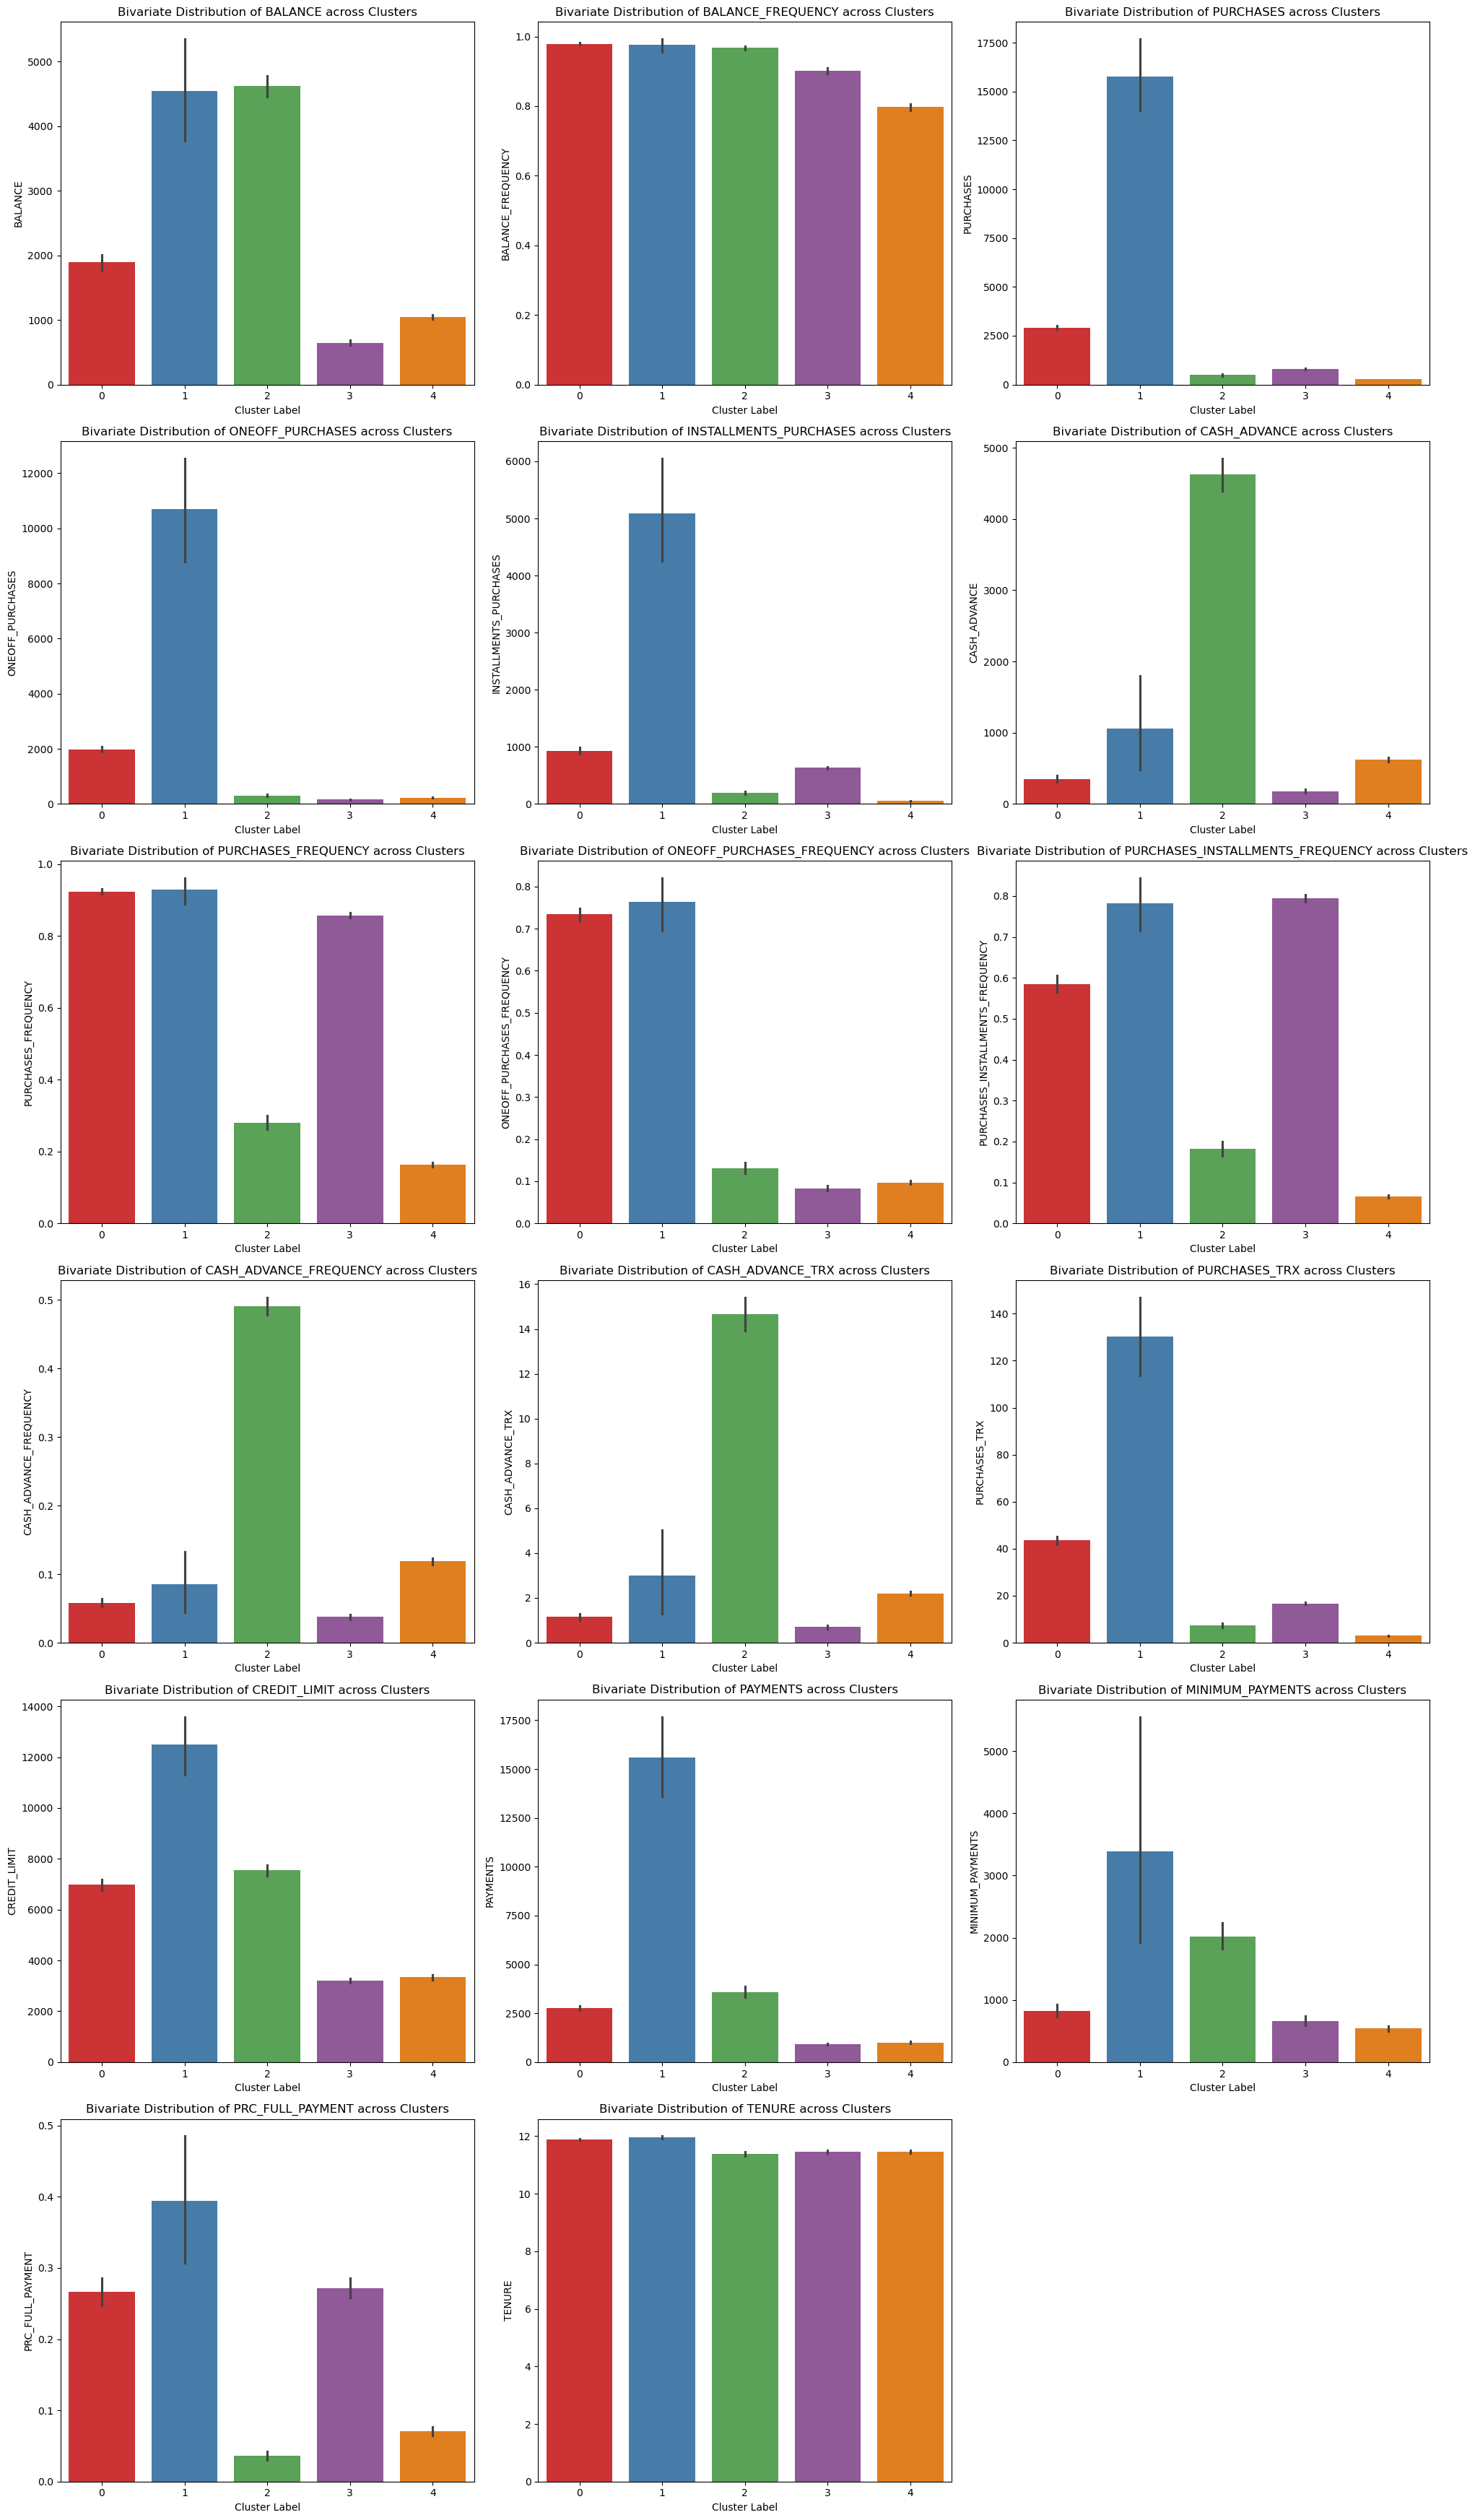

In [34]:
plt.figure(figsize=(20, 35))

cluster_order = sorted(data['KMeans_pred_label'].unique())

for i, col in enumerate(data.columns[:-1]):  
    ax = plt.subplot(6, 3, i + 1)
    sns.barplot(data=data, x='KMeans_pred_label', y=col, palette='Set1', order=cluster_order, hue='KMeans_pred_label', width=0.8)
    
    plt.xlabel('Cluster Label')
    plt.ylabel(col)
    plt.title(f'Bivariate Distribution of {col} across Clusters')
    
    ax.get_legend().remove()
    
plt.tight_layout()

cluster_order = sorted(data['KMeans_pred_label'].unique())

In [35]:
KMeans_stats = KMeans_stats.transpose()
KMeans_stats

KMeans_pred_label,0,1,2,3,4
BALANCE,1893.400240,4541.393882,4616.977320,645.955449,1051.088979
BALANCE_FREQUENCY,0.979339,0.976638,0.967882,0.902331,0.797032
PURCHASES,2916.566171,15777.311395,493.136111,797.744495,278.931482
ONEOFF_PURCHASES,1986.694776,10689.027791,302.052352,166.429623,225.848988
INSTALLMENTS_PURCHASES,930.304921,5088.283605,191.172014,631.809188,53.284815
CASH_ADVANCE,353.408743,1060.190695,4623.363303,178.096535,619.569625
PURCHASES_FREQUENCY,0.923747,0.928101,0.280563,0.856537,0.163421
ONEOFF_PURCHASES_FREQUENCY,0.734122,0.763090,0.130454,0.083195,0.096915
PURCHASES_INSTALLMENTS_FREQUENCY,0.585110,0.781501,0.182218,0.794342,0.065744
CASH_ADVANCE_FREQUENCY,0.058192,0.085271,0.490732,0.038047,0.118664


Using the barplot distribution for each feature's cluster value and the table of features by cluster above, we can perform cluster profiling to determine each cluster's characteristics based on the average (mean) of values in each cluster. We can look at the lowest and highest average values, compare them to the other clusters, and see which features are correlated to build an understanding of each cluster profile's characteristics.

``Cluster 0``: High-volume spenders: These customers have notably high purchases, purchases transactions, and credit limits. This indicates that these are customers who take advantage of their large purchasing power to frequently make purchases in large amounts, especially one-off purchases. We know these customers are active spenders due to their large average number of transactions. We can infer that these customers are likely affluent individuals or businesses with a large amount of cash on hand and significant financial stability, given that they make large purchases and have the greatest ability of repayment (the highest percent of full payments among the clusters).

``Cluster 1``: Moderate spenders: These customers are very similar to the ones in cluster 0, with the second highest purchase and purchases transactions. However, the credit limit and amount paid per purchase is significantly less than the customers of cluster 0. A comparable purchases frequency value indicates that these customers are also very active spenders, but do not make as many high value purchases.

``Cluster 2``: Credit builders: These customers are similar to the ones in cluster 3 if we were to just compare their credit limits. However, these customers differ as they make a greater amount of purchases and on a more frequent basis. This suggests they have a stronger need or desire for credit card usage and are working on building their credit, but at a large scale than the customers of cluster 3.

``Cluster 3``: Entry-level users: These customers have low purchases and purchases frequency. The number of purchase transactions is also the lowest among the clusters, which means that the average customer in the customer rarely makes a purchase with this credit card. We can infer that these customers are likely newer card users and/or students, as their credit limit is on the lower end and the percentage of full payment made is close to 0.

``Cluster 4``: Cash advance users: These customers make the highest amount of cash advances. Their purchases frequency is on the lower end compared to the other clusters, as their cash advances frequency is actually higher. This behavior indicates these customers mostly use this credit card to withdraw cash as a loan, which may suggest financial strain or a lack of an emergency fund.